<a href="https://colab.research.google.com/github/RebeccaTsekanovskiy/CSCI_4170_Spring2026/blob/main/HW6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Section 1 - MDPS

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


# Grid dimensions
ROWS, COLS = 3, 3

# Special states
GOAL = (2, 2)
PIT = (1, 1)
START = (0, 0)

# Actions
actions = ['U', 'D', 'L', 'R']
action_moves = {
    'U': (-1, 0),
    'D': (1, 0),
    'L': (0, -1),
    'R': (0, 1)
}

# Rewards
STEP_REWARD = -1
GOAL_REWARD = 10
PIT_REWARD = -10

# Discount factor
gamma = 0.9

# Convergence threshold
theta = 1e-6

# State space
states = [(r, c) for r in range(ROWS) for c in range(COLS)]

def is_terminal(state):
    return state == GOAL or state == PIT

def next_state(state, action):
    """
    Returns the next state after taking an action.
    If action goes out of bounds, agent stays in same state.
    """
    if is_terminal(state):
        return state

    r, c = state
    dr, dc = action_moves[action]
    nr, nc = r + dr, c + dc

    if nr < 0 or nr >= ROWS or nc < 0 or nc >= COLS:
        return state

    return (nr, nc)

def reward_function(state, action, next_s):
    """
    Reward depends on the state transitioned into.
    """
    if next_s == GOAL:
        return GOAL_REWARD
    elif next_s == PIT:
        return PIT_REWARD
    else:
        return STEP_REWARD

In [14]:
def value_iteration(states, actions, gamma=0.9, theta=1e-6):
    """
    Runs value iteration and returns:
    - V: optimal value function
    - policy: greedy policy derived from V
    """
    V = {s: 0.0 for s in states}

    while True:
        delta = 0

        for s in states:
            if is_terminal(s):
                continue

            old_v = V[s]

            action_values = []
            for a in actions:
                ns = next_state(s, a)
                r = reward_function(s, a, ns)
                q = r + gamma * V[ns]
                action_values.append(q)

            V[s] = max(action_values)
            delta = max(delta, abs(old_v - V[s]))

        if delta < theta:
            break

    policy = {}
    for s in states:
        if s == GOAL:
            policy[s] = 'G'
        elif s == PIT:
            policy[s] = 'X'
        else:
            best_action = None
            best_value = float('-inf')

            for a in actions:
                ns = next_state(s, a)
                r = reward_function(s, a, ns)
                q = r + gamma * V[ns]

                if q > best_value:
                    best_value = q
                    best_action = a

            policy[s] = best_action

    return V, policy

In [22]:
def value_table(V):
    table = np.zeros((ROWS, COLS))
    for r in range(ROWS):
        for c in range(COLS):
            table[r, c] = V[(r, c)]
    return pd.DataFrame(table)

def policy_table(policy):
    arrows = {'U': '↑', 'D': '↓', 'L': '←', 'R': '→', 'G': 'G', 'X': 'X'}
    table = np.empty((ROWS, COLS), dtype=object)
    for r in range(ROWS):
        for c in range(COLS):
            table[r, c] = arrows[policy[(r, c)]]
    return pd.DataFrame(table)

def print_mdp_summary(gamma):
    print("MDP Summary")
    print(f"State space: all 9 cells in the 3x3 grid")
    print(f"Action space: {actions}")
    print("Reward structure:")
    print(f"  normal step: {STEP_REWARD}")
    print(f"  goal: {GOAL_REWARD}")
    print(f"  pit: {PIT_REWARD}")
    print(f"Discount factor gamma: {gamma}")

In [23]:
print_mdp_summary(gamma)

V, policy = value_iteration(states, actions, gamma=gamma, theta=theta)

print("\nLearned Value Function:")
display(value_table(V).round(2))

print("Final Policy:")
display(policy_table(policy))

MDP Summary
State space: all 9 cells in the 3x3 grid
Action space: ['U', 'D', 'L', 'R']
Reward structure:
  normal step: -1
  goal: 10
  pit: -10
Discount factor gamma: 0.9

Learned Value Function:


,0,1,2
0,4.58,6.2,8.0
1,6.20,0.0,10.0
2,8.00,10.0,0.0


Final Policy:


,0,1,2
0,↓,→,↓
1,↓,X,↓
2,→,→,G


In [24]:
gammas = [0.1, 0.9]

results = {}
for g in gammas:
    V_g, policy_g = value_iteration(states, actions, gamma=g, theta=theta)
    results[g] = (V_g, policy_g)

for g in gammas:
    print(f"\n=== Results for gamma = {g} ===")
    print("Value Function:")
    display(value_table(results[g][0]).round(2))
    print("Policy:")
    display(policy_table(results[g][1]))


=== Results for gamma = 0.1 ===
Value Function:


,0,1,2
0,-1.1,-1.0,0.0
1,-1.0,0.0,10.0
2,0.0,10.0,0.0


Policy:


,0,1,2
0,↓,→,↓
1,↓,X,↓
2,→,→,G



=== Results for gamma = 0.9 ===
Value Function:


,0,1,2
0,4.58,6.2,8.0
1,6.20,0.0,10.0
2,8.00,10.0,0.0


Policy:


,0,1,2
0,↓,→,↓
1,↓,X,↓
2,→,→,G


Here, the state space is one of the 9 grid cells.
The agent can choose up,down,left, or right (action space). Each action determines the next state based only on the current state. The agent receives a reward for moving, reaching the goal, or falling into the pit. The future is soley dependent on the current state and action. The reward structure is any step with be -1. But, if you end up at the goal, you will be given 10 points. If you fall into the pit, you will lose 10 points.

With the discount factor of .9, rewards matter a lot, but still less than immediate rewards.


The learned policy choose the action with the highest expected long term return from each state.
It tries to guide the agent toward the goal state, while also making sure it does not fall into the pit.

In the example I provided above, the small experiment is changing the discount factor. The policy can then alter because the agent values future rewards differently.
A larger discount factor makes the agent care about future rewards, meaning that it can wait a little bit longer to receive them. A smaller discount factor makes the agent only want the rewards ASAP and does not want to wait for them as they can be last valuable.

## Section 2 - Mini Research Experiment

Diffusion models ( https://www.ibm.com/think/topics/diffusion-models, https://www.assemblyai.com/blog/diffusion-models-for-machine-learning-introduction, https://arxiv.org/pdf/2006.11239)

The goal of diffusion models are to generate dimensional data, such ass images,audio, or video from random noise.
Diffusion models attempt to solve the big problem of how do we create a model that can sample examples from a distribuition that is both unkown and complex.
Diffusion models break it into small sub problems. First, we must destroy the structure of the data by adding in so much noise so that there is nothing left but noise. Then, a neuiral network gets trained to undo each small noise step. We would repeat this process so that some structure is then uncovered.

This converts the problem to be the following: Given a very noise set of data at a specific timeset, predict what noise was added so that if were to undo it, the clean version would appear.

Specifically, the model is trained using a U-Net architecture that takes a noisy image and the current timestep as input, and learns to predict the noise that was added. The training objective is to minimize the mean squared error between the actual noise added and the model's predicted noise."

In [1]:
pip install diffusers transformers accelerate torch

In [ ]:
from diffusers import StableDiffusionPipeline
import torch

pipe = StableDiffusionPipeline.from_pretrained("runwayml/stable-diffusion-v1-5", torch_dtype=torch.float16)
pipe = pipe.to("cuda")  # or "mps" on Apple Silicon, "cpu" if no GPU


In [11]:

prompts = [
    "a child sitting in a park",
    "a child sitting in a park, photorealistic",
    "a child sitting in a park, oil painting",
    "a child sitting in a park, low quality, blurry",
]

generator = torch.Generator("cuda").manual_seed(42)

images = []
for prompt in prompts:
    img = pipe(prompt, generator=generator).images[0]
    images.append(img)
    img.save(f"output_{prompts.index(prompt)}.png")

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

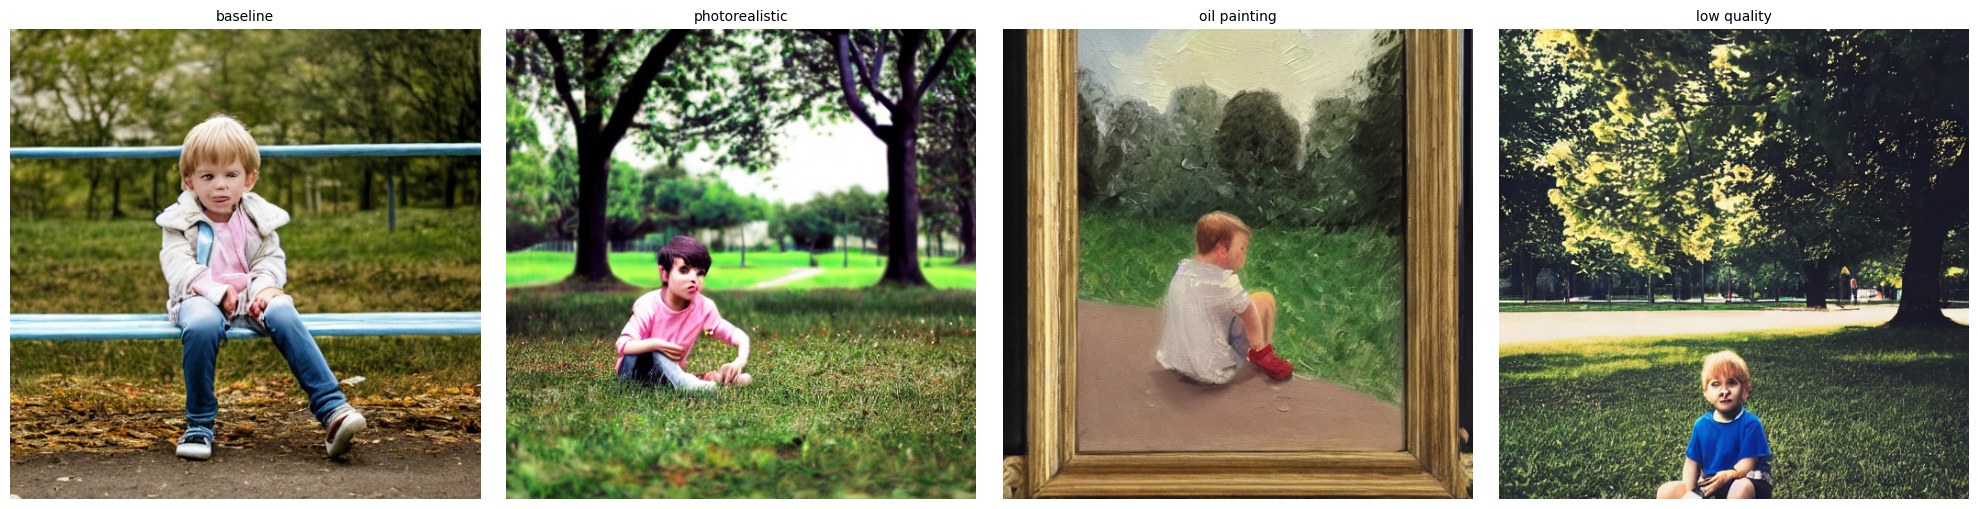

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
titles = ["baseline", "photorealistic", "oil painting", "low quality"]

for ax, img, title in zip(axes, images, titles):
    ax.imshow(img)
    ax.set_title(title, fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.savefig("comparison_grid.png")  # save it too
plt.show()

In the above example, looking past the irregular deformites the boys have, there are a couple key observations. First, in my prompt, I never stated that the child should be a boy. Yet, in all 4 photos, the child is a boy. Also, in the last 3 photos, the boy seems to be grabbing onto his foot for some reason. I wonder if this has something to do with the type of images it was trained on.

### Two Limitations

Prompt sensitivity is a key limitation in the models. Diffusion models are highly sensitive to exact prompt wording. By adding in a couple extra words in the prompt can ultimately change the output produced. There is no known standard way that can predict whether a specific prompt will succeed. This can be noted in the second photo, where I asked if the photo can be photorealistic. Instead, the image generated turned out to be quite the opposite and with deformities.  The model also has no understanding of semantics, but rather can only pair the text tokens with the data it was scraped on.

Training data bias is also another huge problem. The model can memorized some of the copies it was trained on, which leads into its own set of ethical issues, and with the right prompting can lead to the model revealing an image in the training set. Also, simple prompts that dont hint to any gender or race can still cause the model to produce skewed results because it will end up reflecting whatever it was trained on.

A follow up to the experiment would be running the diffusion model with the same prompt, but changing thye amount of guidance it is given. This means I would control how closely the model would listen to the prompt and then understand how the model chaanges the output from its guidance. I would be able to understand the tradeoff and bias in the model.